# Passive single-ended-to-differential converter

This notebook implements a Python-based testbench for the design and verification of the passive SDC used in the 10-bit SAR ADC developed for Chipathon 2026. It automates NGspice simulations while providing a convenient environment for data processing, visualization, and performance evaluation.

The workflow assumes that the SPICE netlist has already been generated from Xschem. After the netlist is available, all simulation parameters are controlled directly from Python. The notebook is organized into independent sections covering **project configuration, simulation setup, waveform import and plotting**.

## Project configuration:

The following libraries are used throughout the notebook. They provide utilities for file management, SPICE netlist editing, simulation execution, data handling, and result visualization.

In [457]:
from pathlib import Path            # Manage file and directory paths
import subprocess                   # Execute external programs (NGspice)
import re                           # Search and replace netlist parameters
import warnings                     # Messages for the set_params function

import numpy as np                  # Numerical computations
import pandas as pd                 # Data import and manipulation
import matplotlib.pyplot as plt     # Plotting
from matplotlib.ticker import EngFormatter  # Engineering notation for axes

The paths shown below correspond to the **IIC Docker container version 2026.06**, where simulation files generated by Xschem are stored under `/headless/.xschem/simulations` and NGspice is installed in `/foss/tools/bin/ngspice`. If a different environment is used, these paths should be updated accordingly.

In [458]:
# Working directory containing the simulation files
WORK_DIR = Path("/headless/.xschem/simulations")

# NGspice executable
NGSPICE = "/foss/tools/bin/ngspice"

# Test-bench name
TB_NAME = "tb_passiveSDC"

# Default plotting style
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Nimbus Roman"],
    "font.size": 11,
})

Simulation parameters are defined in the SPICE netlist and updated automatically from Python, avoiding manual file edits. If a parameter is also redefined inside the `.control` block with a `let` statement, both definitions are updated to keep them consistent.

In [459]:
def set_params(netlist, **params):
    """
    Update multiple settings in a SPICE netlist in a single write operation.

    Supported settings:
      - .param definitions
      - let definitions inside .control
      - MOS process corner (.lib)
      - Resistor process corner (.lib)
      - MIM capacitor process corner (.lib)
      - Simulation temperature (.temp)

    Raises a warning if a setting is not found in the netlist.
    """

    VALID_CORNERS = {
        "typical",
        "ss",
        "sf",
        "fs",
        "ff",
        "statistical",
    }

    netlist = Path(netlist)
    text = netlist.read_text()

    for name, value in params.items():

        name = name.lower()

        # ------------------------------------------------------------
        # MOS process corner
        # ------------------------------------------------------------
        if name == "mos_corner":

            if value.lower() not in VALID_CORNERS:
                raise ValueError(
                    f"Invalid MOS corner '{value}'. "
                    f"Valid options are: {', '.join(sorted(VALID_CORNERS))}."
                )

            text, n = re.subn(
                r"(^\s*\.lib\s+\S+\s+)(typical|ss|sf|fs|ff|statistical)\s*$",
                rf"\g<1>{value}",
                text,
                flags=re.MULTILINE | re.IGNORECASE,
            )

            if n == 0:
                warnings.warn(
                    "MOS corner not updated: no matching .lib statement found.",
                    RuntimeWarning,
                )

        # ------------------------------------------------------------
        # Resistor process corner
        # ------------------------------------------------------------
        elif name == "res_corner":

            if value.lower() not in VALID_CORNERS:
                raise ValueError(
                    f"Invalid resistor corner '{value}'. "
                    f"Valid options are: {', '.join(sorted(VALID_CORNERS))}."
                )

            text, n = re.subn(
                r"(^\s*\.lib\s+\S+\s+)res_(typical|ss|sf|fs|ff|statistical)\s*$",
                rf"\g<1>res_{value}",
                text,
                flags=re.MULTILINE | re.IGNORECASE,
            )

            if n == 0:
                warnings.warn(
                    "Resistor corner not updated: no matching .lib statement found.",
                    RuntimeWarning,
                )

        # ------------------------------------------------------------
        # MIM capacitor process corner
        # ------------------------------------------------------------
        elif name == "cap_corner":

            if value.lower() not in VALID_CORNERS:
                raise ValueError(
                    f"Invalid capacitor corner '{value}'. "
                    f"Valid options are: {', '.join(sorted(VALID_CORNERS))}."
                )

            # Verify that the base MIM capacitor library is present
            if not re.search(
                r"^\s*\.lib\s+\S+\s+cap_mim\s*$",
                text,
                flags=re.MULTILINE | re.IGNORECASE,
            ):
                warnings.warn(
                    "MIM capacitor base library ('cap_mim') not found.",
                    RuntimeWarning,
                )

            # Update the MIM capacitor corner
            text, n = re.subn(
                r"(^\s*\.lib\s+\S+\s+)mimcap_(typical|ss|sf|fs|ff|statistical)\s*$",
                rf"\g<1>mimcap_{value}",
                text,
                flags=re.MULTILINE | re.IGNORECASE,
            )

            if n == 0:
                warnings.warn(
                    "Capacitor corner not updated: no matching mimcap library found.",
                    RuntimeWarning,
                )

        # ------------------------------------------------------------
        # Simulation temperature
        # ------------------------------------------------------------
        elif name == "temp":

            text, n = re.subn(
                r"(^\s*\.temp\s+).*$",
                rf"\g<1>{value}",
                text,
                flags=re.MULTILINE | re.IGNORECASE,
            )

            if n == 0:
                warnings.warn(
                    "Temperature not updated: no .temp statement found.",
                    RuntimeWarning,
                )

        # ------------------------------------------------------------
        # .param and let definitions
        # ------------------------------------------------------------
        else:

            text, n1 = re.subn(
                rf"(^\s*\.param\s+{re.escape(name)}\s*=\s*).*$",
                rf"\g<1>{value}",
                text,
                flags=re.MULTILINE | re.IGNORECASE,
            )

            text, n2 = re.subn(
                rf"(^\s*let\s+{re.escape(name)}\s*=\s*).*$",
                rf"\g<1>{value}",
                text,
                flags=re.MULTILINE | re.IGNORECASE,
            )

            if n1 + n2 == 0:
                warnings.warn(
                    f"Parameter '{name}' not found in .param or let definitions.",
                    RuntimeWarning,
                )

    netlist.write_text(text)

## **Simulation setup and run**

In [460]:
# PVT parameters
MOS_CORNER = "ss"
CAP_CORNER = "typical"
VDD = 3.3
TEMP = 27

# Sampling parameters
Fs = 5e6
Ns = 128
Nc = 13

# Testbench parameters
Nspare = 5
VRP = 2.1
VRN = 1.2

The simulation is launched from the working directory so that all output files, such as exported waveforms, are generated in the work directory. Finally, the NGspice console output is printed to facilitate debugging and verify that the simulation completed successfully.

In [461]:
# SPICE netlist
NETLIST = WORK_DIR / f"{TB_NAME}.spice"

# Simulation parameters
SIM_CONFIG = {
    "mos_corner": MOS_CORNER,
    "cap_corner": CAP_CORNER,
    "temp": TEMP,
    "VDD": VDD,
    "Fs": f"{Fs:g}",
    "Ns": Ns,
    "Nc": Nc,
    "Nspare": Nspare,
    "VRP": VRP,
    "VRN": VRN,
}

set_params(NETLIST, **SIM_CONFIG)

# Run NGspice in batch mode
result = subprocess.run(
    [NGSPICE, "-b", str(NETLIST)],
    cwd=WORK_DIR,
    capture_output=True,
    text=True,
)

# Display the NGspice output
print(result.stdout)

# Print the error log if the simulation failed
if result.returncode != 0:
    print(result.stderr)


Note: Compatibility modes selected: hs a


Circuit: ** sch_path: /foss/designs/chipathon-2026-onchipsar/designs/sar_adc/dac/dac_sw_4state/xschem/tb_passivesdc.sch

Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver

Initial Transient Solution
--------------------------

Node                                   Voltage
----                                   -------
xswp[8].sn[0]                      1.11174e-08
sampn                                      3.3
vss                                          0
vdd                                        3.3
xswp[8].sn[1]                              3.3
cp                                         2.1
xswp[8].net1                               2.1
xswp[8].net2                               2.1
vrp                                        2.1
vrn                                        1.2
xswp[7].sn[0]                      1.11174e-08
xswp[7].sn[1]                              3.3
xswp[7].net1           

## Waveform import

The transient data exported by NGspice is imported into a Pandas DataFrame with descriptive column names. Since `wrdata` generates one time column per waveform, duplicated time vectors are verified for consistency and merged into a single `time` column for subsequent analysis.

In [462]:
data = pd.read_csv(
    WORK_DIR / f"{TB_NAME}.csv",
    sep=r"\s+",
    header=None,
    names=[
        "time", "vin",
        "t_vx", "vx",
        "t_vy", "vy",
        "t_cp", "cp",
        "t_cn", "cn",
    ]
)

# Verify that all time columns are equivalent
if not (
    np.allclose(data["time"], data["t_vx"]) and
    np.allclose(data["time"], data["t_vy"]) and
    np.allclose(data["time"], data["t_cp"]) and
    np.allclose(data["time"], data["t_cn"])
):
    raise ValueError("Time columns are not identical.")

# Keep a single time column
data = data[["time", "vin", "vx", "vy", "cp", "cn"]]

print(data.head())

           time       vin        vx        vy        cp        cn
0  0.000000e+00  1.650000  0.006251  0.004660  2.100000  2.100000
1  8.000000e-10  1.651091  1.044949  0.572377  2.347299  1.867758
2  1.600000e-09  1.652182  1.440755  1.005198  2.168793  1.689969
3  2.400000e-09  1.653274  1.595814  1.155521  2.119578  1.657421
4  3.200000e-09  1.654365  1.639212  1.196102  2.104088  1.657909


## Plot Waveforms

To simplify visualization, only the first input signal period is displayed. Showing both top plate voltages, the bottom plate voltage CN and the differential output.


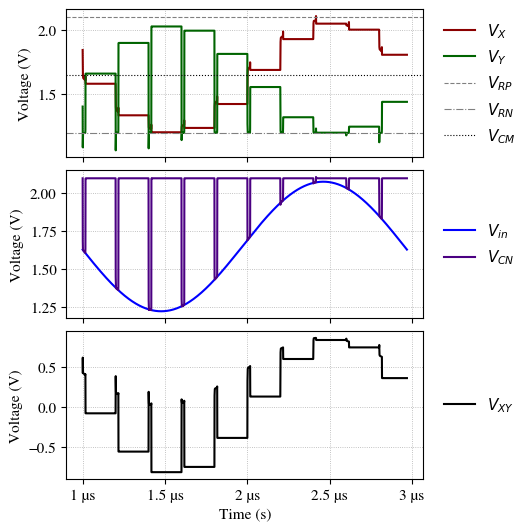

In [463]:
# Compute the input frequency and period
Fin = Nc / Ns * Fs
Tin = 1 / Fin

# Ignore the first Nspare samples
t0 = Nspare / Fs

# Keep one input period after the discarded samples
data_plot = data[
    (data["time"] >= t0) &
    (data["time"] <= t0 + Tin)
].copy()

# Differential voltage
data_plot["vxy"] = data_plot["vx"] - data_plot["vy"]

# Common-mode voltage
VCM = (VRP + VRN) / 2

# Create the figure
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,
    figsize=(5.2, 5.2),
    sharex=True,
    constrained_layout=True,
)

# Plot VX and VY
ax1.plot(data_plot["time"], data_plot["vx"], label=r"$V_X$", color="darkred")
ax1.plot(data_plot["time"], data_plot["vy"], label=r"$V_Y$", color="darkgreen")

ax1.axhline(VRP, color="gray", linestyle="--", linewidth=0.8, label=r"$V_{RP}$")
ax1.axhline(VRN, color="gray", linestyle="-.", linewidth=0.8, label=r"$V_{RN}$")
ax1.axhline(VCM, color="black", linestyle=":", linewidth=0.8, label=r"$V_{CM}$")

ax1.set_ylabel("Voltage (V)")
ax1.grid(True, linestyle=":", linewidth=0.6)
ax1.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

# Plot VIN and CN
ax2.plot(data_plot["time"], data_plot["vin"], label=r"$V_{in}$", color="blue")
ax2.plot(data_plot["time"], data_plot["cn"], label=r"$V_{CN}$", color="indigo")

ax2.set_ylabel("Voltage (V)")
ax2.grid(True, linestyle=":", linewidth=0.6)
ax2.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

# Plot VXY
ax3.plot(data_plot["time"], data_plot["vxy"], label=r"$V_{XY}$", color="black")

ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Voltage (V)")
ax3.grid(True, linestyle=":", linewidth=0.6)
ax3.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

# Display the time axis using engineering notation
ax3.xaxis.set_major_formatter(EngFormatter(unit="s"))

plt.show()